# Assignment 2b
## Title : Binary classification using Deep Neural Networks Example:
Classify movie reviews into
positive" reviews and "negative" reviews, just based on the text content of the reviews. Use
IMDB dataset


Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

Load and Explore Dataset

In [2]:
num_words = 10000
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=num_words)

print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")
print("Example review (encoded):", X_train[0])
print("Sentiment (0 = negative, 1 = positive):", y_train[0])


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000, Testing samples: 25000
Example review (encoded): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12

In [3]:
maxlen = 200

# Pad sequences to uniform length
X_train = pad_sequences(X_train, maxlen=maxlen)
X_test = pad_sequences(X_test, maxlen=maxlen)

print("Padded X_train shape:", X_train.shape)
print("Padded X_test shape:", X_test.shape)

Padded X_train shape: (25000, 200)
Padded X_test shape: (25000, 200)


Build the DNN Model

In [4]:
model = Sequential([
    Embedding(input_dim=num_words, output_dim=32, input_length=maxlen),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Train the Model

In [5]:
history = model.fit(X_train, y_train,
                    epochs=10,
                    batch_size=512,
                    validation_split=0.2,
                    verbose=1)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - accuracy: 0.5296 - loss: 0.6899 - val_accuracy: 0.7390 - val_loss: 0.6126
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 108ms/step - accuracy: 0.8066 - loss: 0.4941 - val_accuracy: 0.8478 - val_loss: 0.3469
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - accuracy: 0.9000 - loss: 0.2540 - val_accuracy: 0.8640 - val_loss: 0.3174
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.9474 - loss: 0.1584 - val_accuracy: 0.8686 - val_loss: 0.3125
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - accuracy: 0.9796 - loss: 0.0845 - val_accuracy: 0.8448 - val_loss: 0.4053
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.9849 - loss: 0.0633 - val_accuracy: 0.8606 - val_loss: 0.3748
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.9954 - loss: 0.0312 - val_accuracy: 0.8686 - val_loss: 0.3770
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 123ms/step - accuracy: 0.9972 - loss: 0.0200 - val_accuracy: 0.8586 -

In [6]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}, Test Loss: {test_loss:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8615 - loss: 0.4447
Test Accuracy: 0.8609, Test Loss: 0.4487


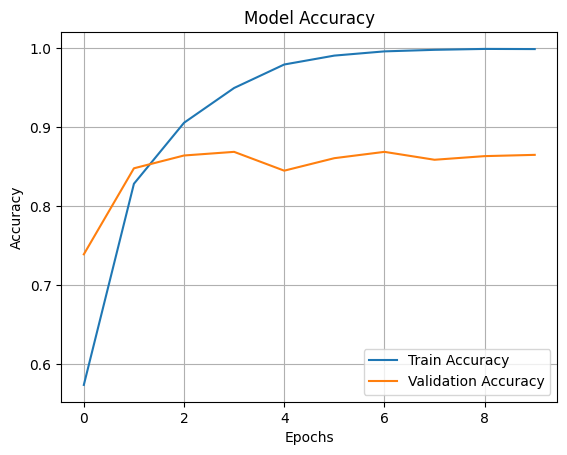

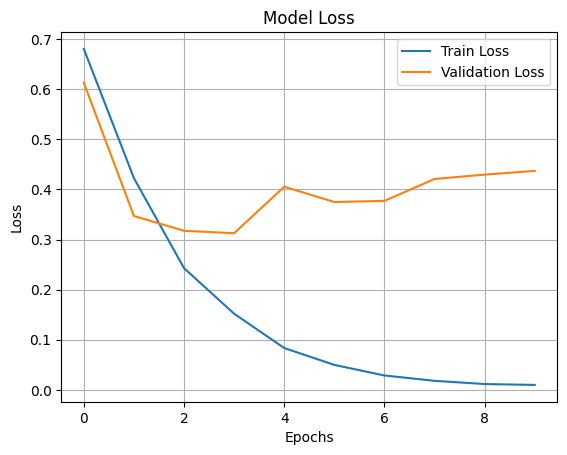

In [7]:
# Accuracy plot
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

# Loss plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

# Conclusion

- The DNN with embedding and dense layers was able to classify reviews with high accuracy (>85%).
- Simple architectures like this are effective but can be improved using RNNs or transformers.
- Padding and truncation allowed us to handle variable-length sequences.
- The dataset is balanced and clean, ideal for learning text classification tasks.